In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torchvision.transforms.functional as TF
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
class FourLayerWideNetwork(nn.Module):
    def __init__(self, num_classes=100, width_factor=1):
        super(FourLayerWideNetwork, self).__init__()

        c1 = 32  * width_factor
        c2 = 64  * width_factor
        c3 = 128 * width_factor
        c4 = 256 * width_factor

        self.features = nn.Sequential(
            # Layer1
            nn.Conv2d(3,  c1, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(c1),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # Layer2
            nn.Conv2d(c1, c2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            nn.GELU(),
            nn.Dropout(0.1),

            # Layer3
            nn.Conv2d(c2, c3, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(c3),
            nn.GELU(),
            nn.Dropout(0.1),

            # Layer4
            nn.Conv2d(c3, c4, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(c4),
            nn.GELU(),
            nn.Dropout(0.1),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256 * width_factor, num_classes),
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [3]:
# 計算模型參數量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class MiniImageNetDataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        
        # 讀取txt文件中的路徑和標籤
        with open(txt_file, 'r') as f:
            for line in f:
                img_path, label = line.strip().split()
                self.data.append((img_path, int(label)))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        full_path = os.path.join(self.root_dir, img_path)
        
        img = Image.open(full_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# 輔助函數
def get_transforms():
    # 訓練集的轉換
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),  # ResNet34預設輸入尺寸為224x224
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 驗證集的轉換
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

def load_datasets(root_dir, txt_dir, train_transform, val_transform, batch_size):
    """載入mini-ImageNet數據集"""
    # 創建訓練和驗證數據集
    train_dataset = MiniImageNetDataset(
        txt_file=os.path.join(txt_dir, 'train.txt'),
        root_dir=root_dir,
        transform=train_transform
    )
    
    val_dataset = MiniImageNetDataset(
        txt_file=os.path.join(txt_dir, 'val.txt'),
        root_dir=root_dir,
        transform=val_transform
    )
    
    # 創建數據加載器
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    return train_loader, val_loader

def save_checkpoint(model, optimizer, epoch, filename):
    """保存模型檢查點"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    torch.save(checkpoint, filename)
    print(f"檢查點已保存至 {filename}")

# 設定隨機種子以獲得可重複的結果
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

# 使用tqdm的訓練函數
def train_epoch(model, dataloader, criterion, optimizer, device):
    """訓練一個epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="訓練中", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 清零梯度
        optimizer.zero_grad()
        
        # 前向傳播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向傳播和優化
        loss.backward()
        optimizer.step()
        
        # 統計
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # 更新進度條
        pbar.set_postfix({"損失": f"{loss.item():.4f}", "準確率": f"{100. * correct / total:.2f}%"})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

# 使用tqdm的驗證函數
def validate(model, dataloader, criterion, device):
    """驗證模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="驗證中", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 前向傳播
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 統計
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # 更新進度條
            pbar.set_postfix({"損失": f"{loss.item():.4f}", "準確率": f"{100. * correct / total:.2f}%"})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [14]:
# 設置隨機種子
set_seed()

# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用設備: {device}")

# 定義數據路徑
root_dir = 'dataset'
txt_dir = 'dataset'

# 獲取數據轉換
train_transform, val_transform = get_transforms()

# 載入數據
batch_size = 32
print("正在載入數據集...")
train_loader, val_loader = load_datasets(root_dir, txt_dir, train_transform, val_transform, batch_size)
print(f"已載入訓練集 {len(train_loader.dataset)} 張圖片和驗證集 {len(val_loader.dataset)} 張圖片")

print("正在創建模型...")
model = FourLayerWideNetwork(num_classes=100, width_factor=6).to(device)

# 打印模型參數數量
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"模型參數總數: {total_params:,}")

# 設定訓練參數
num_epochs = 15

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
# scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.5)


# 設定checkpoint目錄
checkpoint_dir = "Taskb_checkpoints/wide_four"
os.makedirs(checkpoint_dir, exist_ok=True)

使用設備: cuda
正在載入數據集...
已載入訓練集 63325 張圖片和驗證集 450 張圖片
正在創建模型...
模型參數總數: 37,715,236


開始訓練 15 個epoch...
Epoch 1/15


訓練損失: 3.7446, 訓練準確率: 0.1100
驗證損失: 3.4875, 驗證準確率: 0.1711
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.1711)
Epoch 2/15


訓練損失: 3.4792, 訓練準確率: 0.1717
驗證損失: 3.1094, 驗證準確率: 0.2511
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.2511)
Epoch 3/15


訓練損失: 3.3068, 訓練準確率: 0.2157
驗證損失: 2.9915, 驗證準確率: 0.2556
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.2556)
Epoch 4/15


訓練損失: 3.1891, 訓練準確率: 0.2459
驗證損失: 2.9773, 驗證準確率: 0.3000
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.3000)
Epoch 5/15


...

訓練損失: 2.6075, 訓練準確率: 0.4181
驗證損失: 2.3179, 驗證準確率: 0.5044
Epoch 13/15


訓練損失: 2.4995, 訓練準確率: 0.4563
驗證損失: 2.1932, 驗證準確率: 0.5556
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.5556)
Epoch 14/15


訓練損失: 2.4727, 訓練準確率: 0.4639
驗證損失: 2.1521, 驗證準確率: 0.5689
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.5689)
Epoch 15/15


訓練損失: 2.4454, 訓練準確率: 0.4732
驗證損失: 2.1622, 驗證準確率: 0.5889
檢查點已保存至 Taskb_checkpoints/wide_four/best_model_w6.pth
新的最佳模型已保存 (驗證準確率: 0.5889)
檢查點已保存至 Taskb_checkpoints/wide_four/epoch_15.pth


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

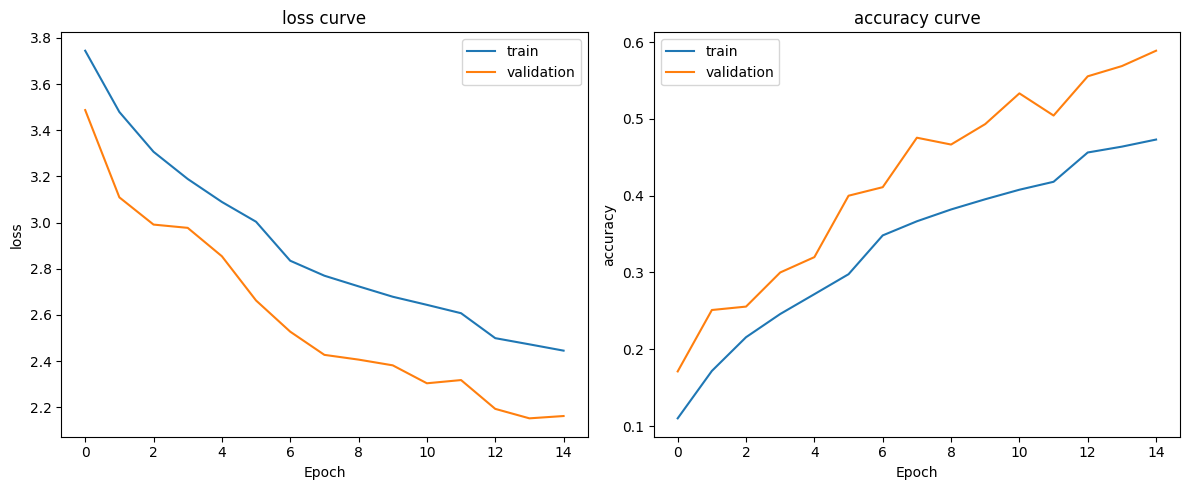

訓練完成! 最佳驗證準確率: 0.5889


In [15]:
# 開始訓練
best_val_acc = 0.0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print(f"開始訓練 {num_epochs} 個epoch...")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    # 訓練一個epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 驗證
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # 再更新 ReduceLROnPlateau
    scheduler.step()
    
    print(f"訓練損失: {train_loss:.4f}, 訓練準確率: {train_acc:.4f}")
    print(f"驗證損失: {val_loss:.4f}, 驗證準確率: {val_acc:.4f}")
    
    # 保存模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(model, optimizer, epoch, f"{checkpoint_dir}/best_model_w6.pth")
        print(f"新的最佳模型已保存 (驗證準確率: {val_acc:.4f})")
    if (epoch + 1) % 5 == 0:
        save_checkpoint(model, optimizer, epoch, f"{checkpoint_dir}/epoch_{epoch+1}.pth")

# 繪製訓練過程圖
plt.figure(figsize=(12, 5))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # 設置字體以支持繁體中文

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.title('loss curve')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train')
plt.plot(val_accs, label='validation')
plt.title('accuracy curve')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f"{checkpoint_dir}/training_curves_w6.png")
plt.show()

print(f"訓練完成! 最佳驗證準確率: {best_val_acc:.4f}")